# A.3 Segmenterad beskrivning

Det här notebooken analyserar hur skadefrekvensen varierar mellan olika segment i portföljen:

- skadefrekvens per `Verksamhet`
- skadefrekvens per `GeografisktOmrade`
- skadefrekvens per `Ar`
- Duration som exponeringsvariabel
- heatmap för `Verksamhet × GeografisktOmrade`

Varje analys kompletteras med en visualisering.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

data_dir = Path("../../../data")
df = pd.read_csv(data_dir / "Entreprenadförsäkring training.csv")

print(f"Träning: {df.shape[0]:,} rader")

Träning: 1,033,386 rader


## 1. Fördelning mellan verksamheter

I det här avsnittet jämförs både portföljens sammansättning och skadefrekvensen mellan olika verksamhetstyper.

In [3]:
business_share = (
    df["Verksamhet"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("Verksamhet")
    .reset_index(name="Andel av portföljen (%)")
)

business_claim_rate = (
    df.groupby("Verksamhet", observed=False)
    .agg(
        Skador=("AntalSkador", "sum"),
        Exponeringsar=("Duration", "sum"),
    )
    .assign(**{"Skador per exponerat år": lambda x: x["Skador"] / x["Exponeringsar"]})
    .sort_values("Skador per exponerat år", ascending=False)
    .reset_index()
)

display(business_share)
display(business_claim_rate[["Verksamhet", "Skador", "Exponeringsar", "Skador per exponerat år"]])

,Verksamhet,Andel av portföljen (%)
0,Byggföretag,39.960963
1,Övriga specialistföretag,16.988134
2,Målare,10.051810
3,Elektriker,9.991717
4,VVS,9.983685
5,Grävning & Schaktning,8.033397
6,Takarbeten,4.990294


,Verksamhet,Skador,Exponeringsar,Skador per exponerat år
0,VVS,2916,92337.610290,0.031580
1,Takarbeten,1153,46086.227627,0.025018
2,Byggföretag,8161,369045.227225,0.022114
3,Övriga specialistföretag,3368,157093.027357,0.021440
4,Grävning & Schaktning,1401,74282.906272,0.018860
5,Elektriker,1424,92277.213728,0.015432
6,Målare,1307,92916.911204,0.014066


/var/folders/d5/4jc8gct96d9dww_5r98m795c0000gn/T/ipykernel_54713/2842539000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


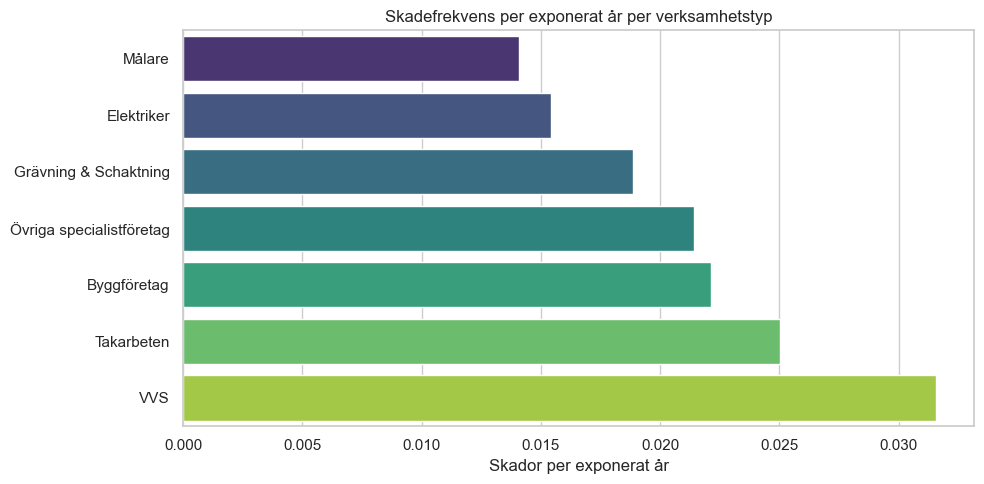

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = business_claim_rate.sort_values("Skador per exponerat år")
sns.barplot(
    data=plot_data,
    x="Skador per exponerat år",
    y="Verksamhet",
    ax=ax,
    palette="viridis",
)
ax.set_title("Skadefrekvens per exponerat år per verksamhetstyp")
ax.set_xlabel("Skador per exponerat år")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Tolkning

Största verksamhetsgrupperna i träningsdatan är:

- Byggföretag: 39,96 %
- Övriga specialistföretag: 16,99 %
- Målare: 10,05 %
- Elektriker: 9,99 %
- VVS: 9,98 %

Skadefrekvensen varierar tydligt mellan verksamhetstyper. VVS sticker ut mest (~0,032), följt av Takarbeten (~0,025). Målare och Elektriker har lägst skadefrekvens (~0,014–0,015). Det här är ett starkt argument för att Verksamhet ska vara en central variabel i modelleringen.

## 2. Fördelning mellan geografiska områden

Här analyseras hur portföljen är fördelad mellan geografiska områden och hur skadefrekvensen varierar mellan dessa grupper.

In [5]:
geography_share = (
    df["GeografisktOmrade"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("Geografiskt område")
    .reset_index(name="Andel av portföljen (%)")
)

geography_claim_rate = (
    df.groupby("GeografisktOmrade", observed=False)
    .agg(
        Skador=("AntalSkador", "sum"),
        Exponeringsar=("Duration", "sum"),
    )
    .assign(**{"Skador per exponerat år": lambda x: x["Skador"] / x["Exponeringsar"]})
    .sort_values("Skador per exponerat år", ascending=False)
    .reset_index()
    .rename(columns={"GeografisktOmrade": "Geografiskt område"})
)

display(geography_share)
display(geography_claim_rate)

,Geografiskt område,Andel av portföljen (%)
0,Storstad,40.001026
1,Mellanstorstad,29.975633
2,Småstad,20.026592
3,Landsbyggd,9.996749


,Geografiskt område,Skador,Exponeringsar,Skador per exponerat år
0,Storstad,9632,369423.929844,0.026073
1,Mellanstorstad,5951,277157.057746,0.021472
2,Landsbyggd,1651,92262.660299,0.017895
3,Småstad,2496,185195.475815,0.013478


/var/folders/d5/4jc8gct96d9dww_5r98m795c0000gn/T/ipykernel_54713/3605670515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


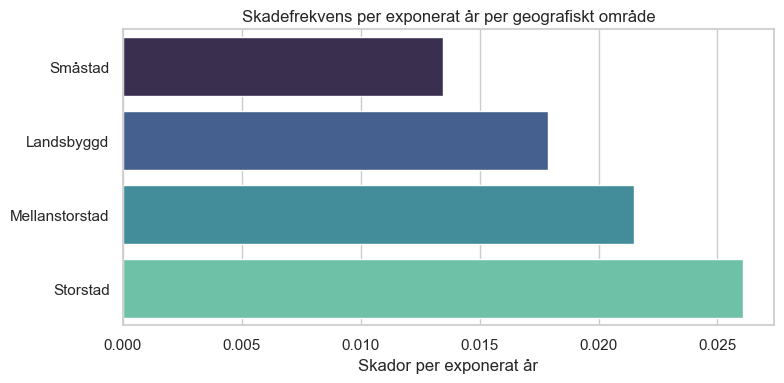

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = geography_claim_rate.sort_values("Skador per exponerat år")
sns.barplot(
    data=plot_data,
    x="Skador per exponerat år",
    y="Geografiskt område",
    ax=ax,
    palette="mako",
)
ax.set_title("Skadefrekvens per exponerat år per geografiskt område")
ax.set_xlabel("Skador per exponerat år")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Tolkning

Portföljens geografiska fördelning:

- Storstad: 40,0 %
- Mellanstorstad: 30,0 %
- Småstad: 20,0 %
- Landsbyggd: 10,0 %

Storstad har klart högst skadefrekvens (~0,026), medan Småstad ligger lägst (~0,014). Gradient från stad till land är tydlig. Det tyder på att marknadstyp eller arbetsmiljö skiljer sig åt på ett sätt som påverkar risknivån. Geografi är alltså också en viktig förklaringsfaktor.

## 3. Skillnader över tid

Här studeras hur skadefrekvensen utvecklas mellan kalenderåren i träningsdatan.

In [7]:
year_summary = (
    df.groupby("Ar", observed=False)
    .agg(
        **{
            "Antal rader": ("Ar", "size"),
            "Totala skador": ("AntalSkador", "sum"),
            "Exponeringsår": ("Duration", "sum"),
        }
    )
    .assign(**{"Skador per exponerat år": lambda x: x["Totala skador"] / x["Exponeringsår"]})
    .reset_index()
    .rename(columns={"Ar": "År"})
)

year_summary["År"] = year_summary["År"].astype(int)
year_summary[["År", "Antal rader", "Totala skador", "Skador per exponerat år"]]

,År,Antal rader,Totala skador,Skador per exponerat år
0,2021,239213,4565,0.021343
1,2022,252034,4627,0.020529
2,2023,264444,5092,0.021537
3,2024,277695,5446,0.021930


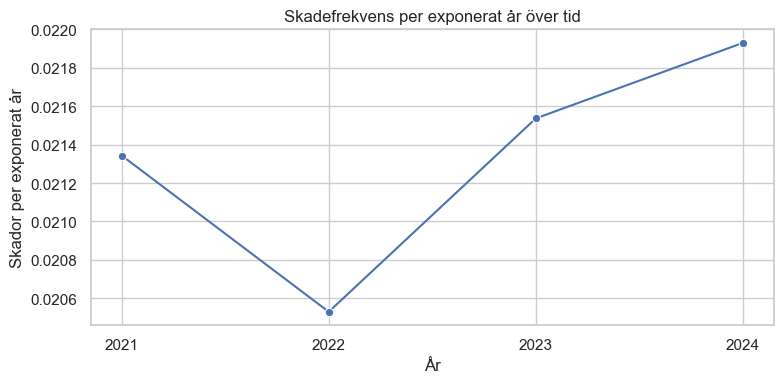

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    data=year_summary,
    x="År",
    y="Skador per exponerat år",
    marker="o",
    ax=ax,
)
ax.set_title("Skadefrekvens per exponerat år över tid")
ax.set_xlabel("År")
ax.set_ylabel("Skador per exponerat år")
ax.set_xticks(year_summary["År"].values)
plt.tight_layout()
plt.show()

### Tolkning

Ingen dramatisk trend, men en svag rörelse uppåt från 2022 till 2024. Portföljen växer samtidigt i antal observationer och exponering. Detta stödjer uppgiftsbeskrivningens poäng om att skadebeteenden kan förändras över tid och att år därför bör finnas med i modellen.

## 4. Duration och exponering

I det här avsnittet undersöks om skadefrekvensen är stabil när observationerna delas upp efter hur stor del av året försäkringen varit aktiv. Om frekvensen per exponerat år är stabil över duration-grupper stödjer det att Duration fungerar som exponeringsvariabel.

In [9]:
duration_bins = [0, 0.25, 0.5, 0.75, 0.99, 1.0]
duration_labels = [
    "0 till 0,25 år",
    "0,25 till 0,5 år",
    "0,5 till 0,75 år",
    "0,75 till 0,99 år",
    "0,99 till 1,0 år",
]

duration_band = pd.cut(
    df["Duration"],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True,
    right=True,
)

duration_summary = (
    df.assign(DurationBand=duration_band)
    .groupby("DurationBand", observed=False)
    .agg(
        **{
            "Antal rader": ("Duration", "size"),
            "Totala skador": ("AntalSkador", "sum"),
            "Exponeringsår": ("Duration", "sum"),
        }
    )
    .assign(**{"Skador per exponerat år": lambda x: x["Totala skador"] / x["Exponeringsår"]})
    .reset_index()
    .rename(columns={"DurationBand": "Duration-intervall"})
)

duration_summary[["Duration-intervall", "Antal rader", "Totala skador", "Skador per exponerat år"]]

,Duration-intervall,Antal rader,Totala skador,Skador per exponerat år
0,"0 till 0,25 år",32260,108,0.019189
1,"0,25 till 0,5 år",64238,534,0.021882
2,"0,5 till 0,75 år",81940,1068,0.020688
3,"0,75 till 0,99 år",100047,1893,0.021633
4,"0,99 till 1,0 år",754901,16127,0.021364


### Tolkning

Skadefrekvensen per exponerat år är ganska stabil över duration-grupperna (0,019–0,022). Det är ett bra tecken: det tyder på att Duration fungerar som en rimlig exponeringsvariabel. För modelleringen betyder det att vi bör använda Duration som offset i Poisson-GLM snarare än som en vanlig förklarande variabel.

## 5. Verksamhet × Geografi — heatmap

Här kombineras verksamhet och geografi för att visa skadefrekvensen för alla kombinationer i en heatmap. Detta ger en överblick av om det finns interaktionseffekter utöver de enskilda huvudeffekterna.

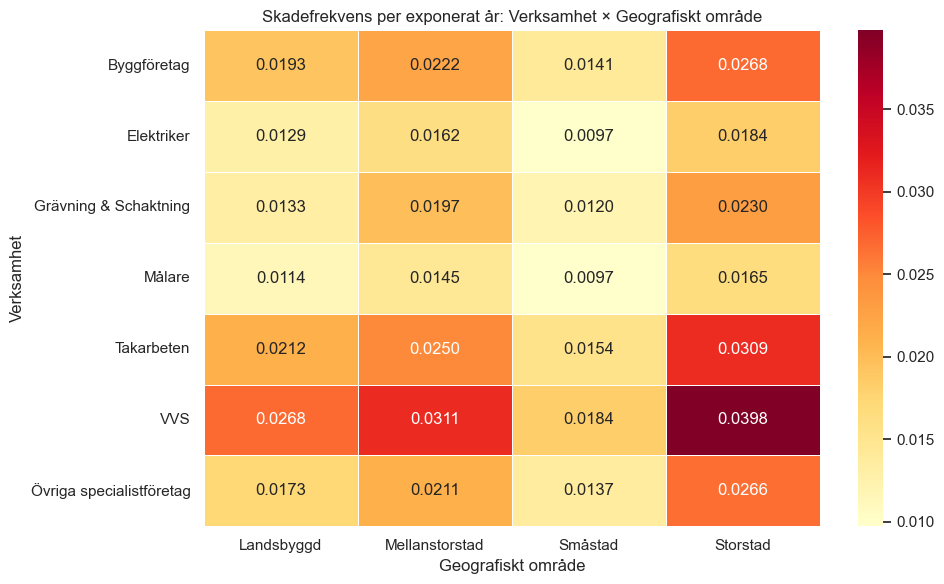

In [10]:
business_geography_combo = (
    df.groupby(["Verksamhet", "GeografisktOmrade"], observed=False)
    .agg(
        Skador=("AntalSkador", "sum"),
        Exponeringsar=("Duration", "sum"),
    )
    .assign(**{"Skador per exponerat år": lambda x: x["Skador"] / x["Exponeringsar"]})
    .reset_index()
)

heatmap_data = business_geography_combo.pivot(
    index="Verksamhet",
    columns="GeografisktOmrade",
    values="Skador per exponerat år",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Skadefrekvens per exponerat år: Verksamhet × Geografiskt område")
ax.set_ylabel("Verksamhet")
ax.set_xlabel("Geografiskt område")
plt.tight_layout()
plt.show()

### Tolkning

Heatmappen visar alla kombinationer av verksamhet och geografi. De högsta skadefrekvenserna finns i:

- VVS i Storstad (~0,040)
- VVS i Mellanstorstad (~0,031)
- Takarbeten i Storstad (~0,031)
- Byggföretag i Storstad (~0,027)

Mönstret ser till stor del additivt ut — Storstad höjer genomgående och VVS höjer genomgående — men vissa kombinationer (t.ex. VVS × Storstad) verkar ha ännu högre frekvens än vad enbart rad- och kolumneffekter skulle förutsäga. Det kan vara relevant att testa interaktioner i modellen, men det är en valfri fördjupning enligt planen.